<a href="https://colab.research.google.com/github/AgacheM/Analyzing-Toronto-Airbnb-Dataset/blob/main/CIND_820_Notebook_1_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Import Libraries**

In [44]:
#Import Libraries
#Exploratory Data Analysis
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Format without scientific notation
pd.options.display.float_format = '{:,.0f}'.format

#Formatting
from IPython.display import display

# **2. Download Listings & Reviews Data from Insideairbnb.com**

In [45]:
#Import Listings file
url_1 = "https://data.insideairbnb.com/canada/on/toronto/2025-11-11/data/listings.csv.gz"
df_listings=pd.read_csv(url_1, compression='gzip', index_col='id')

In [46]:
#Summarize Listings Data #Summarize
print(f"""
DATASET OVERVIEW
----------------
Rows: {df_listings.shape[0]:,}
Columns: {df_listings.shape[1]}
""")

print(f"""
FIRST 5 ROWS
---------------""")
display(df_listings.head())


DATASET OVERVIEW
----------------
Rows: 21,468
Columns: 78


FIRST 5 ROWS
---------------


,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
id,,,,,,,,,,,,,,,,,,,,,
1419,https://www.airbnb.com/rooms/1419,20251111064035,2025-11-11,previous scrape,Beautiful home in amazing area!,"This large, family home is located in one of T...",The apartment is located in the Ossington stri...,https://a0.muscache.com/pictures/76206750/d643...,1565,https://www.airbnb.com/users/show/1565,...,5,5,5,NaN,f,1,1,0,0,0
8077,https://www.airbnb.com/rooms/8077,20251111064035,2025-11-11,previous scrape,Downtown Harbourfront Private Room,Guest room in a luxury condo with access to al...,NaN,https://a0.muscache.com/pictures/11780344/141c...,22795,https://www.airbnb.com/users/show/22795,...,5,5,5,NaN,f,2,1,1,0,1
26654,https://www.airbnb.com/rooms/26654,20251111064035,2025-11-11,city scrape,"World Class @ CN Tower, convention centre, The...","CN Tower, TIFF Bell Lightbox, Metro Convention...",There's a reason they call it the Entertainmen...,https://a0.muscache.com/pictures/81811785/5dcd...,113345,https://www.airbnb.com/users/show/113345,...,5,5,5,NaN,f,3,3,0,0,0
27423,https://www.airbnb.com/rooms/27423,20251111064035,2025-11-12,city scrape,Executive Studio Unit- Ideal for One Person,"Brand new, fully furnished studio basement apa...",NaN,https://a0.muscache.com/pictures/176936/b687ed...,118124,https://www.airbnb.com/users/show/118124,...,5,5,5,NaN,f,1,1,0,0,0
30931,https://www.airbnb.com/rooms/30931,20251111064035,2025-11-11,previous scrape,Downtown Toronto - Waterview Condo,Split level waterfront condo with a breathtaki...,NaN,https://a0.muscache.com/pictures/227971/e8ebd7...,22795,https://www.airbnb.com/users/show/22795,...,NaN,NaN,NaN,NaN,f,2,1,1,0,0


In [47]:
#Data Types
print ("\n Data Types:")
display(df_listings.dtypes.to_frame(name="Type"))

print("\n Basic Statistics:")
display(df_listings.drop(columns=['listing_id'],errors='ignore').describe())


 Data Types:


,Type
listing_url,object
scrape_id,int64
last_scraped,object
source,object
name,object
...,...
calculated_host_listings_count,int64
calculated_host_listings_count_entire_homes,int64
calculated_host_listings_count_private_rooms,int64
calculated_host_listings_count_shared_rooms,int64



 Basic Statistics:


,scrape_id,host_id,host_listings_count,host_total_listings_count,neighbourhood_group_cleansed,latitude,longitude,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,"21,468","21,468","21,452","21,452",0,"21,468","21,468","21,468","15,799","19,801",...,"16,614","16,613","16,613","16,612","16,613","21,468","21,468","21,468","21,468","16,615"
mean,"20,251,111,064,035","249,662,036",7,11,NaN,44,-79,3,1,2,...,5,5,5,5,5,5,2,3,0,1
std,8,"230,033,337",19,33,NaN,0,0,2,1,1,...,0,0,0,0,0,12,5,11,0,2
min,"20,251,111,064,035","1,565",1,1,NaN,44,-80,1,0,0,...,0,0,1,1,0,1,0,0,0,0
25%,"20,251,111,064,035","38,325,618",1,1,NaN,44,-79,2,1,1,...,5,5,5,5,5,1,0,0,0,0
50%,"20,251,111,064,035","167,522,830",2,3,NaN,44,-79,2,1,1,...,5,5,5,5,5,1,1,0,0,1
75%,"20,251,111,064,035","471,703,128",4,7,NaN,44,-79,4,2,2,...,5,5,5,5,5,3,1,2,0,2
max,"20,251,111,064,035","728,337,308",335,622,NaN,44,-79,16,20,50,...,5,5,5,5,5,121,47,118,10,34


In [48]:
#Calculate Missing Values
print ("Missing Values:")
missing = df_listings.isnull().sum()
missing = missing[missing>0]

missing_percent=(missing/len(df_listings))*100

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

#View only columns with missing values
missing_summary = missing_summary[missing_summary["Missing Count"]>0]

#Correct Errors
if len(missing_summary) > 0:
    display(
        missing_summary
        .sort_values (by="Missing %", ascending= False)
        .style.format({
            "Missing Count": "{:,.0f}",
            "Missing %": "{:.2f}%"
        })
        .background_gradient(cmap="Reds")
    )
else:
    print ("No Missing Values Found")

Missing Values:


,Missing Count,Missing %
neighbourhood_group_cleansed,"21,468",100.00%
calendar_updated,"21,468",100.00%
host_neighbourhood,"14,025",65.33%
neighborhood_overview,"12,011",55.95%
neighbourhood,"12,010",55.94%
host_about,"11,621",54.13%
license,"11,074",51.58%
host_response_rate,"6,806",31.70%
host_response_time,"6,806",31.70%
host_acceptance_rate,"5,924",27.59%


In [49]:
#Handle the missing valules
#Drop columns with >50% missing values
columns_to_drop = missing_summary[missing_summary["Missing %"]>50].index
df_listings = df_listings.drop(columns=columns_to_drop)

print(f"Dropped {len(columns_to_drop)} columns with high missing values.")
print("Columns to Drop:")
print(columns_to_drop)

print ("Missing Values:")
missing = df_listings.isnull().sum()
missing = missing[missing>0]

missing_percent=(missing/len(df_listings))*100

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

#View only columns with missing values
missing_summary = missing_summary[missing_summary["Missing Count"]>0]

#Correct Errors
if len(missing_summary) > 0:
    display(
        missing_summary
        .sort_values (by="Missing %", ascending= False)
        .style.format({
            "Missing Count": "{:,.0f}",
            "Missing %": "{:.2f}%"
        })
        .background_gradient(cmap="Reds")
    )
else:
    print ("No Missing Values Found")



Dropped 7 columns with high missing values.
Columns to Drop:
Index(['neighborhood_overview', 'host_about', 'host_neighbourhood',
       'neighbourhood', 'neighbourhood_group_cleansed', 'calendar_updated',
       'license'],
      dtype='object')
Missing Values:


,Missing Count,Missing %
host_response_rate,"6,806",31.70%
host_response_time,"6,806",31.70%
host_acceptance_rate,"5,924",27.59%
host_location,"5,717",26.63%
beds,"5,669",26.41%
bathrooms,"5,669",26.41%
estimated_revenue_l365d,"5,659",26.36%
price,"5,659",26.36%
review_scores_location,"4,856",22.62%
review_scores_communication,"4,855",22.62%


In [50]:
#Handle Missing Values
#Categorical
#Numerical > Mean, Median?


In [55]:
#Preprocess Data
#Clean Price from String to Numerical
df_listings['price'] = df_listings['price'].replace(r'[\$,]', '', regex=True).astype(float)


print("💰 Cleaned Price Values:")
print(df_listings['price'].head())


💰 Cleaned Price Values:
id
1419    NaN
8077    NaN
26654   133
27423    75
30931   NaN
Name: price, dtype: float64


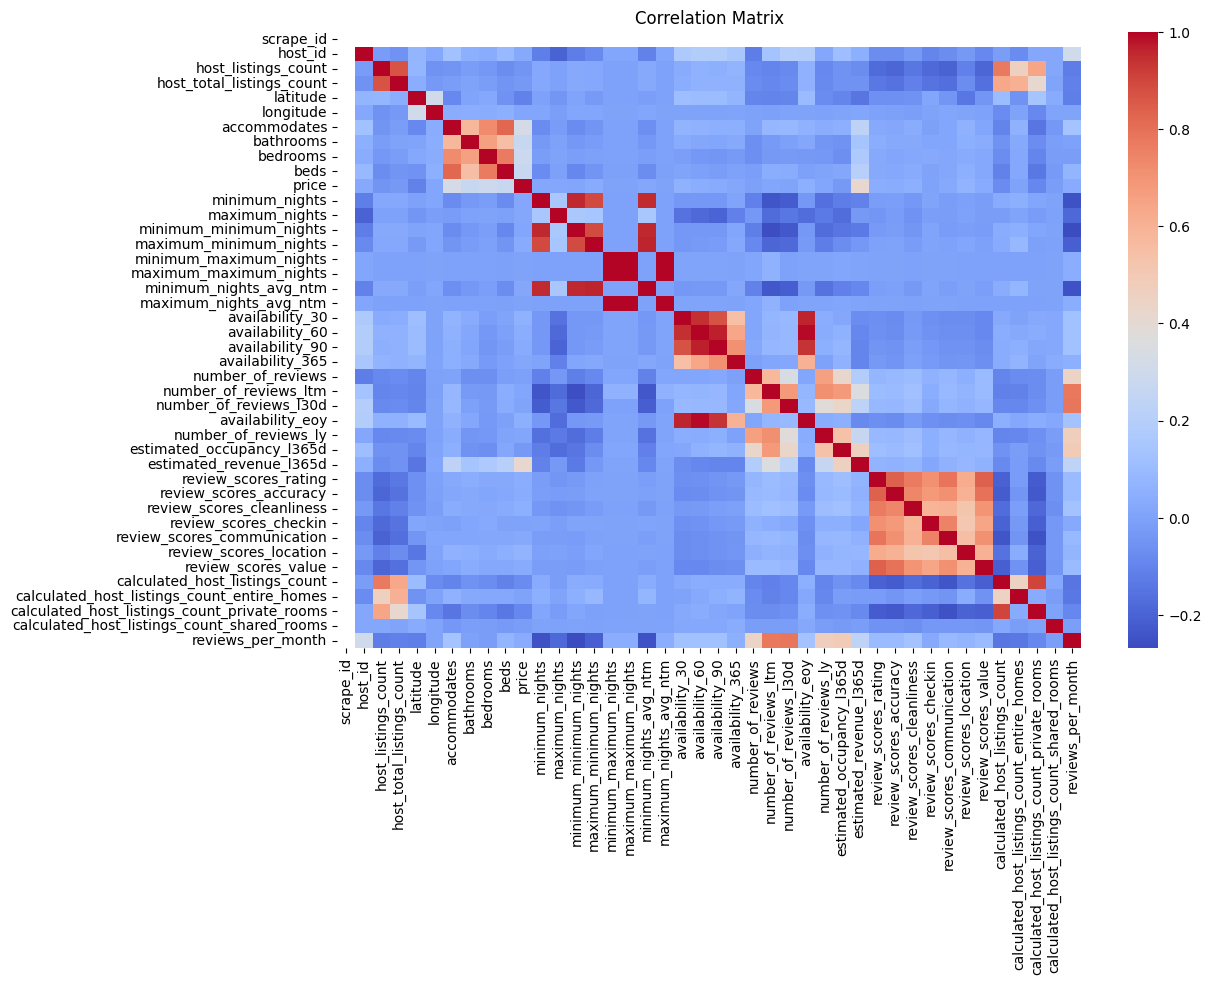

In [56]:
#Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df_listings.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title("Correlation Matrix")
plt.show()
